In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [64]:


# filename = "/Users/jkueny/projects/HR4796a_lco2023a_magao-x_20230309_10/raws_20230310T054736_s_lyot_stop/camsci2/norm_lite_psflib/klip_fm_files/camsci2_z_20230309_10_klbasis.h5"
# filename = "/Users/jkueny/projects/HR4796_rg_smlyot_20230312_13/raws_rg_smlyot_20230313T043914/camsci1/lite_psflib/klip_fm_files/camsci1_r_20230312_13_klbasis.h5"
filename = "/Users/jkueny/projects/HR4796_rg_smlyot_20230312_13/raws_rg_smlyot_20230313T043914/camsci2/lite_psflib/klip_fm_files/camsci2_g_20230312_13_klbasis.h5"


In [48]:
def _recursively_load_dict_contents_from_group(h5file, path):
    """
    Recursively explore the dictionnary for loading it

    Args:
        h5file: the file from which we load, opened with h5py.File
        path: the separator to aggregate the keys. Should be the same one used in
        _recursively_save_dict_contents_to_group
    Returns
        the rebuilt dictionnary
    """

    ans = {}
    for key, item in h5file[path].items():
        if isinstance(item, h5py._hl.dataset.Dataset):
            ans[key] = item[()]
        elif isinstance(item, h5py._hl.group.Group):
            ans[key] = _recursively_load_dict_contents_from_group(
                h5file, path + key + '/')
    return ans

In [49]:
def _load_dict_from_hdf5(filename):
    """
    Load a dictionnary from a h5 file

    Args:
        filename: the filename of the h5

    Returns:
        the dictionnary exctracted

    """

    with h5py.File(filename, "r") as h5file:
        return _recursively_load_dict_contents_from_group(h5file, '/')

In [65]:
klbasis = _load_dict_from_hdf5(filename)

#### KL basis file contents
+ `aligned_images_dict`
  - Library of aligned science PSF images.
  - Each of size (N_images, xdim * ydim)
    + e.g. (84, 50176) for z' band dataset.
  - Only 1 dict key "wl1000" b/c we use single wavelength cubes.
+ `evals_dict`
  - Assoc. eigenvalues
  - Each of size (1, N_KLmodes)?
  - Dict keys of section ids
    + Ex. idsec101i000 and idsec101i083
+ `evecs_dict`
  - Assoc. eigenvectors
  - Each of size (N_refimages, N_KLmodes)
  - Dict keys of section ids
    + Ex. idsec101i000 and idsec101i083
+ `input_img_num_dict`
  - This is just the literal image number in the sequence.
  - Results in 1 for idsec101i001 and 83 for idsec101i083, etc.
+ `klmodes_dict`
  - Each mode of (currently) unknown size.
    + for the z' dataset, each mode vector is (1,39112)
      - modes for each image is (2, 391112) because we only use 2 KL modes to subtract PSF.
  - Dict keys of section ids
    + Ex. idsec101i000 and idsec101i083
+ `klparam_dict`
  - Keys
    + ['IWA', 'OWA', 'PAs', 'aligned_center_x', 'aligned_center_y', 'input_img_shape', 'isRDI', 'nfiles', 'numbasis', 'nwvs', 'output_imgs_shape', 'wvs']
  - `input_img_shape = [224. 224.]` (ex.)
  - `output_img_shape = [84., 224., 224., 1]` (ex.)
    + (N_files, xdim, ydim, N_wvs)
+`ref_psfs_indicies_dict`
  - np array of integer indices for the images to use for the basis for a given image.
+ `section_ind_dict`
  - array indicies into the 2-D x-y image that correspond to a section.
    + As an example, for the HR4796 data we mask out pixels interior to the IWA and exterior to the OWA. This is our 1 section we care about.
    + This is why the number of elements in this array is less than the expected 224**2 = 50176
  - Size of one of these items is, e.g., (1,39112).
    + 224 square image, IWA 10, OWA 112

In [66]:
print(klbasis.keys())

dict_keys(['aligned_images_dict', 'evals_dict', 'evecs_dict', 'input_img_num_dict', 'klmodes_dict', 'klparam_dict', 'phiend_dict', 'phistart_dict', 'radend_dict', 'radstart_dict', 'ref_psfs_indicies_dict', 'section_ind_dict'])


In [52]:
print(klbasis['aligned_images_dict'].keys())

dict_keys(['wl1000'])


In [67]:
print(klbasis['input_img_num_dict'].keys())

dict_keys(['idsec101i000', 'idsec101i001', 'idsec101i002', 'idsec101i003', 'idsec101i004', 'idsec101i005', 'idsec101i006', 'idsec101i007', 'idsec101i008', 'idsec101i009', 'idsec101i010', 'idsec101i011', 'idsec101i012', 'idsec101i013', 'idsec101i014', 'idsec101i015', 'idsec101i016', 'idsec101i017', 'idsec101i018', 'idsec101i019', 'idsec101i020', 'idsec101i021', 'idsec101i022', 'idsec101i023', 'idsec101i024', 'idsec101i025', 'idsec101i026', 'idsec101i027', 'idsec101i028', 'idsec101i029', 'idsec101i030', 'idsec101i031', 'idsec101i032', 'idsec101i033', 'idsec101i034', 'idsec101i035', 'idsec101i036', 'idsec101i037', 'idsec101i038', 'idsec101i039', 'idsec101i040', 'idsec101i041', 'idsec101i042', 'idsec101i043', 'idsec101i044', 'idsec101i045', 'idsec101i046', 'idsec101i047', 'idsec101i048', 'idsec101i049', 'idsec101i050', 'idsec101i051', 'idsec101i052', 'idsec101i053', 'idsec101i054', 'idsec101i055', 'idsec101i056', 'idsec101i057', 'idsec101i058', 'idsec101i059', 'idsec101i060', 'idsec101i061

In [68]:
sample_input_img_num = klbasis["input_img_num_dict"]["idsec101i000"]
print(sample_input_img_num)

0


In [11]:
print(klbasis['section_ind_dict'].values())

dict_values([array([[  101,   102,   103, ..., 50072, 50073, 50074]], shape=(1, 39112)), array([[  101,   102,   103, ..., 50072, 50073, 50074]], shape=(1, 39112)), array([[  101,   102,   103, ..., 50072, 50073, 50074]], shape=(1, 39112)), array([[  101,   102,   103, ..., 50072, 50073, 50074]], shape=(1, 39112)), array([[  101,   102,   103, ..., 50072, 50073, 50074]], shape=(1, 39112)), array([[  101,   102,   103, ..., 50072, 50073, 50074]], shape=(1, 39112)), array([[  101,   102,   103, ..., 50072, 50073, 50074]], shape=(1, 39112)), array([[  101,   102,   103, ..., 50072, 50073, 50074]], shape=(1, 39112)), array([[  101,   102,   103, ..., 50072, 50073, 50074]], shape=(1, 39112)), array([[  101,   102,   103, ..., 50072, 50073, 50074]], shape=(1, 39112)), array([[  101,   102,   103, ..., 50072, 50073, 50074]], shape=(1, 39112)), array([[  101,   102,   103, ..., 50072, 50073, 50074]], shape=(1, 39112)), array([[  101,   102,   103, ..., 50072, 50073, 50074]], shape=(1, 39112)),

In [7]:
print(klbasis['klmodes_dict'].keys())

dict_keys(['idsec101i000', 'idsec101i001', 'idsec101i002', 'idsec101i003', 'idsec101i004', 'idsec101i005', 'idsec101i006', 'idsec101i007', 'idsec101i008', 'idsec101i009', 'idsec101i010', 'idsec101i011', 'idsec101i012', 'idsec101i013', 'idsec101i014', 'idsec101i015', 'idsec101i016', 'idsec101i017', 'idsec101i018', 'idsec101i019', 'idsec101i020', 'idsec101i021', 'idsec101i022', 'idsec101i023', 'idsec101i024', 'idsec101i025', 'idsec101i026', 'idsec101i027', 'idsec101i028', 'idsec101i029', 'idsec101i030', 'idsec101i031', 'idsec101i032', 'idsec101i033', 'idsec101i034', 'idsec101i035', 'idsec101i036', 'idsec101i037', 'idsec101i038', 'idsec101i039', 'idsec101i040', 'idsec101i041', 'idsec101i042', 'idsec101i043', 'idsec101i044', 'idsec101i045', 'idsec101i046', 'idsec101i047', 'idsec101i048', 'idsec101i049', 'idsec101i050', 'idsec101i051', 'idsec101i052', 'idsec101i053', 'idsec101i054', 'idsec101i055', 'idsec101i056', 'idsec101i057', 'idsec101i058', 'idsec101i059', 'idsec101i060', 'idsec101i061

In [36]:
sample_klmode = klbasis['klmodes_dict']["idsec101i000"]
print(sample_klmode)
print(sample_klmode.shape)

[[ 0.00081012  0.00081722  0.00080125 ...  0.00070904  0.00073935
   0.00070198]
 [ 0.00156398  0.00152908  0.00149373 ... -0.00094307 -0.00093559
  -0.00102759]]
(2, 39112)


In [17]:
print(klbasis['klparam_dict'].keys())

dict_keys(['IWA', 'OWA', 'PAs', 'aligned_center_x', 'aligned_center_y', 'input_img_shape', 'isRDI', 'nfiles', 'numbasis', 'nwvs', 'output_imgs_shape', 'wvs'])


In [21]:
sample_klparam = klbasis['klparam_dict']["output_imgs_shape"]
print(sample_klparam)

[ 84. 224. 224.   1.]


In [30]:
sample_val = klbasis["aligned_images_dict"]['wl1000']
print(sample_val.shape)

(84, 50176)


In [32]:
sample_klmode = klbasis['klmodes_dict']['idsec101i001']
print(sample_klmode.shape)

(2, 39112)


In [37]:
print(klbasis['evals_dict'].keys())

dict_keys(['idsec101i000', 'idsec101i001', 'idsec101i002', 'idsec101i003', 'idsec101i004', 'idsec101i005', 'idsec101i006', 'idsec101i007', 'idsec101i008', 'idsec101i009', 'idsec101i010', 'idsec101i011', 'idsec101i012', 'idsec101i013', 'idsec101i014', 'idsec101i015', 'idsec101i016', 'idsec101i017', 'idsec101i018', 'idsec101i019', 'idsec101i020', 'idsec101i021', 'idsec101i022', 'idsec101i023', 'idsec101i024', 'idsec101i025', 'idsec101i026', 'idsec101i027', 'idsec101i028', 'idsec101i029', 'idsec101i030', 'idsec101i031', 'idsec101i032', 'idsec101i033', 'idsec101i034', 'idsec101i035', 'idsec101i036', 'idsec101i037', 'idsec101i038', 'idsec101i039', 'idsec101i040', 'idsec101i041', 'idsec101i042', 'idsec101i043', 'idsec101i044', 'idsec101i045', 'idsec101i046', 'idsec101i047', 'idsec101i048', 'idsec101i049', 'idsec101i050', 'idsec101i051', 'idsec101i052', 'idsec101i053', 'idsec101i054', 'idsec101i055', 'idsec101i056', 'idsec101i057', 'idsec101i058', 'idsec101i059', 'idsec101i060', 'idsec101i061

In [38]:
sample_eval = klbasis['evals_dict']['idsec101i000']
print(sample_eval)

[360.14475243   4.96720685]


In [40]:
sample_evec = klbasis['evecs_dict']['idsec101i000']
print(sample_evec.shape)

(73, 2)


In [51]:
print(klbasis['ref_psfs_indicies_dict'].keys())

KeyError: 'ref_psfs_indicies_dict'

In [ ]:


sample_refpsfindex = klbasis['ref_psfs_indicies_dict']['idsec101i000']
# print(sample_refpsfindex)

all_refs = []
n_refs = []

for k in klbasis["ref_psfs_indicies_dict"].keys():
    ref_psfs = klbasis["ref_psfs_indicies_dict"][k]
    # all_refs.append(ref_psfs)
    n_refs.append(int(ref_psfs.shape[0]))

# print(all_refs)
print(n_refs)

[81, 80, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 78, 79, 79, 79, 79, 80, 79, 79, 79, 79, 79, 78, 79, 79, 78, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 80, 81]


In [32]:
print(klbasis['section_ind_dict'].keys())

dict_keys(['idsec101i000', 'idsec101i001', 'idsec101i002', 'idsec101i003', 'idsec101i004', 'idsec101i005', 'idsec101i006', 'idsec101i007', 'idsec101i008', 'idsec101i009', 'idsec101i010', 'idsec101i011', 'idsec101i012', 'idsec101i013', 'idsec101i014', 'idsec101i015', 'idsec101i016', 'idsec101i017', 'idsec101i018', 'idsec101i019', 'idsec101i020', 'idsec101i021', 'idsec101i022', 'idsec101i023', 'idsec101i024', 'idsec101i025', 'idsec101i026', 'idsec101i027', 'idsec101i028', 'idsec101i029', 'idsec101i030', 'idsec101i031', 'idsec101i032', 'idsec101i033', 'idsec101i034', 'idsec101i035', 'idsec101i036', 'idsec101i037', 'idsec101i038', 'idsec101i039', 'idsec101i040', 'idsec101i041', 'idsec101i042', 'idsec101i043', 'idsec101i044', 'idsec101i045', 'idsec101i046', 'idsec101i047', 'idsec101i048', 'idsec101i049', 'idsec101i050', 'idsec101i051', 'idsec101i052', 'idsec101i053', 'idsec101i054', 'idsec101i055', 'idsec101i056', 'idsec101i057', 'idsec101i058', 'idsec101i059', 'idsec101i060', 'idsec101i061

In [71]:
sample_sectionind = klbasis["section_ind_dict"]["idsec101i000"]
print(sample_sectionind)

[[  101   102   103 ... 50072 50073 50074]]


## View the KL modes

In [72]:
# sampleKL = klbasis["klmodes_dict"]["idsec18026i000"]
sampleKL = klbasis["klmodes_dict"]["idsec101i000"]
# sample_section_ind = klbasis["section_ind_dict"]["idsec18026i000"]
sample_section_ind = klbasis["section_ind_dict"]["idsec101i000"]
sample_image = klbasis["aligned_images_dict"]["wl1000"][0]

nominal_dimension = int(np.sqrt(sample_image.shape))

img_dim = nominal_dimension, nominal_dimension

print(img_dim)
print(sampleKL.shape)

(224, 224)
(16, 38616)


/var/folders/cq/5nwgl8t100q9dcc39ryp_lmc0000gn/T/ipykernel_51165/4101366380.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nominal_dimension = int(np.sqrt(sample_image.shape))


##### Only the indices corresponding to the region of interest are saved

+ Need to tie the section_inds to insert into a full image
  - This is in the klbasis["section_inds_dict"]

In [109]:
from dev.pyklip.fmlib.funcs_JDFM import insert_section_into_full_image

sample_full_image = insert_section_into_full_image(sampleKL[15], img_dim, sample_section_ind)


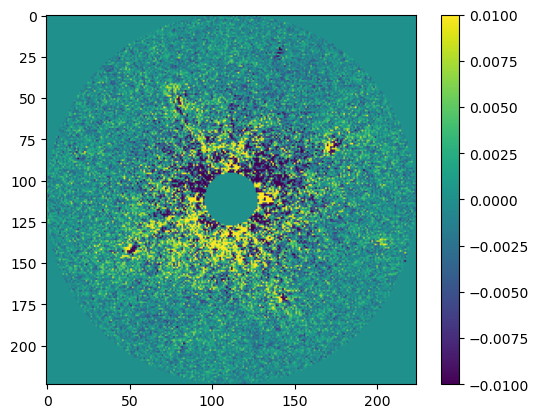

In [110]:
plt.imshow(sample_full_image,
           vmin=-0.01, vmax=0.01)
plt.colorbar()
